### DESCRIPTION

**Sentiment Analysis using BERT + HuggingFace (PyTorch)**

**Dataset**: tweet_eval (Sentiment) dari HuggingFace Datasets

**Model** : bert-base-uncased

**Task** : 3-class Sentiment Classification (Negative / Neutral / Positive)

---

**Work Step:**
1. Setup & Installation
2. Load Dataset
3. Exploratory Data Analysis (EDA)
4. Preprocessing & Tokenization
5. Model BERT & Optimizer
6. Training Loop
7. Evaluation & Metrics
8. Inferense
9. Inference Result Visualization

### 1. SETUP & INSTALLATION

In [1]:
# Install dependencies
!pip install transformers datasets torch torchmetrics scikit-learn matplotlib seaborn tqdm accelerate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 37.6 MB/s eta 0:00:00


In [2]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.auto import tqdm
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from datasets import load_dataset
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ PyTorch version  : {torch.__version__}")
print(f"✅ Device           : {DEVICE}")
print(f"✅ CUDA Available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✅ GPU              : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM             : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

✅ PyTorch version  : 2.10.0+cu128
✅ Device           : cuda
✅ CUDA Available   : True
✅ GPU              : Tesla T4
   VRAM             : 15.6 GB


### 2. LOAD DATA

In [3]:
print("\n⏳ Loading tweet_eval/sentiment dataset...")
dataset = load_dataset("tweet_eval", "sentiment")
print("✅ Dataset loaded successfully!\n", dataset)


⏳ Loading tweet_eval/sentiment dataset...


README.md: 0.00B [00:00, ?B/s]

sentiment/train-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

sentiment/test-00000-of-00001.parquet:   0%|          | 0.00/901k [00:00<?, ?B/s]

sentiment/validation-00000-of-00001.parq(…):   0%|          | 0.00/167k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

✅ Dataset loaded successfully!
 DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [4]:
# Convert to DataFrames
train_df = pd.DataFrame(dataset["train"])
val_df   = pd.DataFrame(dataset["validation"])
test_df  = pd.DataFrame(dataset["test"])

In [5]:
# Label mapping
LABEL_MAP  = {0: "Negative", 1: "Neutral", 2: "Positive"}
NUM_LABELS = 3

for df in (train_df, val_df, test_df):
    df["label_name"] = df["label"].map(LABEL_MAP)

In [6]:
print(f"Train size      : {len(train_df):,}")
print(f"Validation size : {len(val_df):,}")
print(f"Test size       : {len(test_df):,}")
print("\nSample data:")
train_df.head()

Train size      : 45,615
Validation size : 2,000
Test size       : 12,284

Sample data:


,text,label,label_name
0,"""QT @user In the original draft of the 7th boo...",2,Positive
1,"""Ben Smith / Smith (concussion) remains out of...",1,Neutral
2,Sorry bout the stream last night I crashed out...,1,Neutral
3,Chase Headley's RBI double in the 8th inning o...,1,Neutral
4,@user Alciato: Bee will invest 150 million in ...,2,Positive


### 3. EXPLORATORY DATA ANALYSIS (EDA)

In [7]:
print("\n🔍 Missing Values")
print(train_df.isnull().sum())


🔍 Missing Values
text          0
label         0
label_name    0
dtype: int64


In [8]:
duplicate_count = train_df.duplicated(subset="text").sum()
print(f"\n🔁 Duplicate tweets in train set: {duplicate_count}")


🔁 Duplicate tweets in train set: 29


In [9]:
if duplicate_count > 0:
    train_df = train_df.drop_duplicates(subset="text").reset_index(drop=True)
    print(f"   → After removing duplicates: {len(train_df):,} samples")

   → After removing duplicates: 45,586 samples


In [10]:
print("\n📊 Label Distribution (Count)")
print(train_df["label_name"].value_counts())


📊 Label Distribution (Count)
label_name
Neutral     20655
Positive    17840
Negative     7091
Name: count, dtype: int64


In [11]:
print("\n📊 Label Distribution (%)")
print((train_df["label_name"].value_counts(normalize=True) * 100).round(2))


📊 Label Distribution (%)
label_name
Neutral     45.31
Positive    39.13
Negative    15.56
Name: proportion, dtype: float64


**Plot 1: Label Distribution per Split**

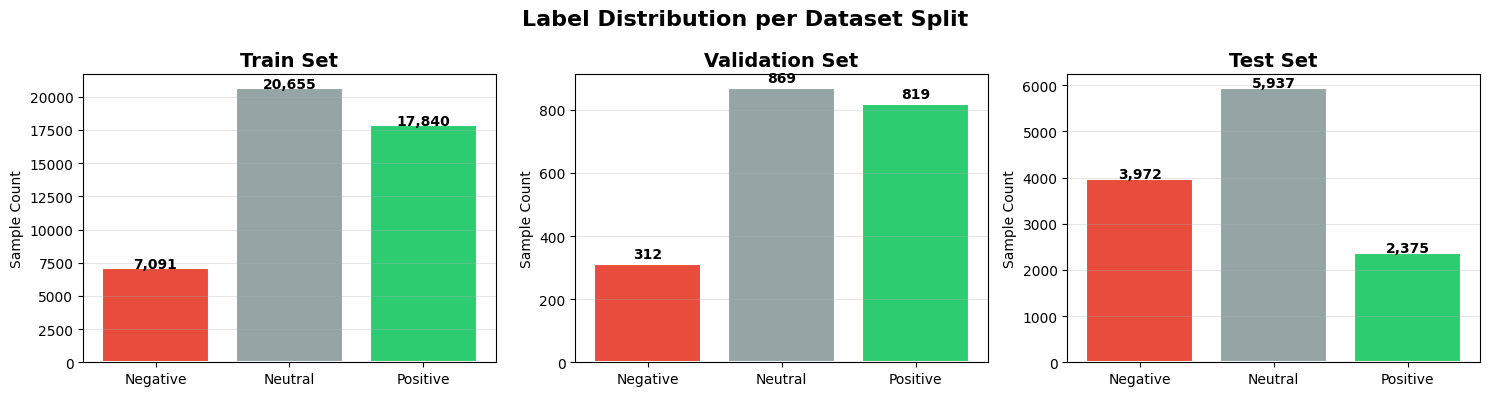

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ["#e74c3c", "#95a5a6", "#2ecc71"]

for ax, (df, name) in zip(
    axes,
    [(train_df, "Train"), (val_df, "Validation"), (test_df, "Test")],
):
    counts = df["label_name"].value_counts().reindex(["Negative", "Neutral", "Positive"])
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor="white", linewidth=1.5)
    ax.set_title(f"{name} Set", fontsize=14, fontweight="bold")
    ax.set_ylabel("Sample Count")
    ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 20,
            f"{val:,}",
            ha="center", fontsize=10, fontweight="bold",
        )

plt.suptitle("Label Distribution per Dataset Split", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_01_label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

**Text Length Statictics**

In [13]:
train_df["text_length"] = train_df["text"].str.len()
train_df["word_count"] = train_df["text"].str.split().apply(len)

print("\n📏 Text Length Statistics")
print(train_df[["text_length", "word_count"]].describe().round(2))


📏 Text Length Statistics
       text_length  word_count
count     45586.00    45586.00
mean        106.94       19.24
std          26.25        4.94
min          10.00        1.00
25%          89.00       16.00
50%         113.00       20.00
75%         128.00       23.00
max         200.00       35.00


**Plot 2: Character & Word Length Distribution**

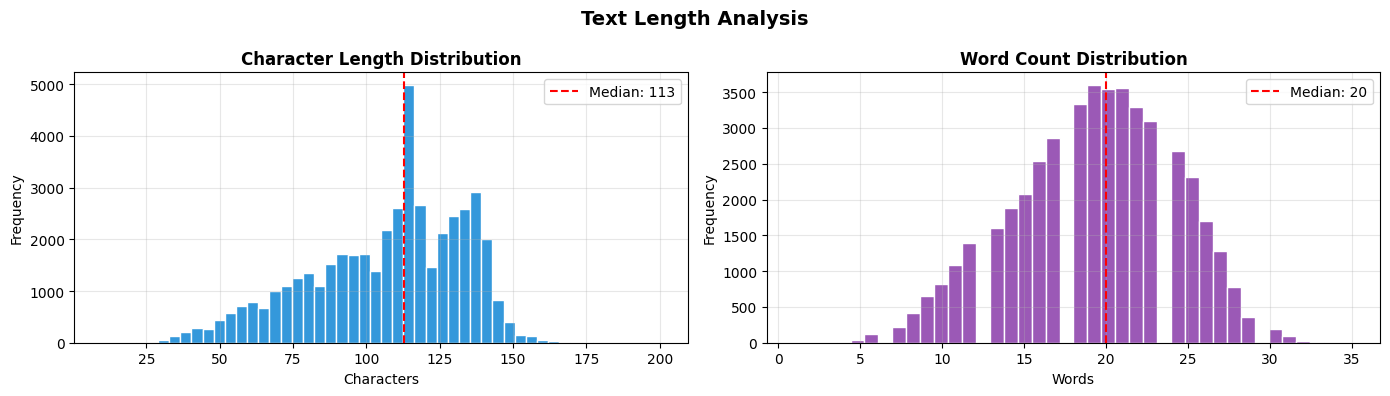

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train_df["text_length"], bins=50, edgecolor="white", color="#3498db")
axes[0].axvline(train_df["text_length"].median(), color="red", linestyle="--",
                label=f"Median: {train_df['text_length'].median():.0f}")
axes[0].set_title("Character Length Distribution", fontweight="bold")
axes[0].set_xlabel("Characters"); axes[0].set_ylabel("Frequency")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(train_df["word_count"], bins=40, edgecolor="white", color="#9b59b6")
axes[1].axvline(train_df["word_count"].median(), color="red", linestyle="--",
                label=f"Median: {train_df['word_count'].median():.0f}")
axes[1].set_title("Word Count Distribution", fontweight="bold")
axes[1].set_xlabel("Words"); axes[1].set_ylabel("Frequency")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("Text Length Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_02_length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

**Plot 3: Word Count per Sentiment**

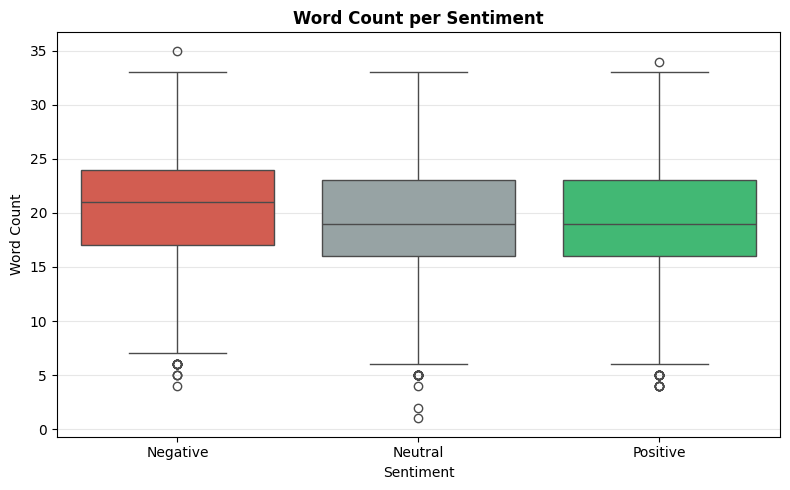

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=train_df,
    x="label_name",
    y="word_count",
    order=["Negative", "Neutral", "Positive"],
    hue="label_name",
    palette={"Negative": "#e74c3c", "Neutral": "#95a5a6", "Positive": "#2ecc71"},
    legend=False
)
plt.title("Word Count per Sentiment", fontweight="bold")
plt.xlabel("Sentiment"); plt.ylabel("Word Count")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("plot_03_wordcount_per_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()

**Plot 4: Top 20 Most Frequent Words**


🔤 Top 20 Most Frequent Words (stopwords removed)
        word  count
0        may   6405
1   tomorrow   4497
2       will   3584
3         he   3014
4      going   2929
5        see   2718
6        day   2652
7        all   2611
8        out   2581
9         if   2578
10     about   2389
11      like   2376
12        as   2320
13       get   2188
14        up   2157
15     night   2049
16       his   1983
17        by   1928
18        go   1816
19      time   1806


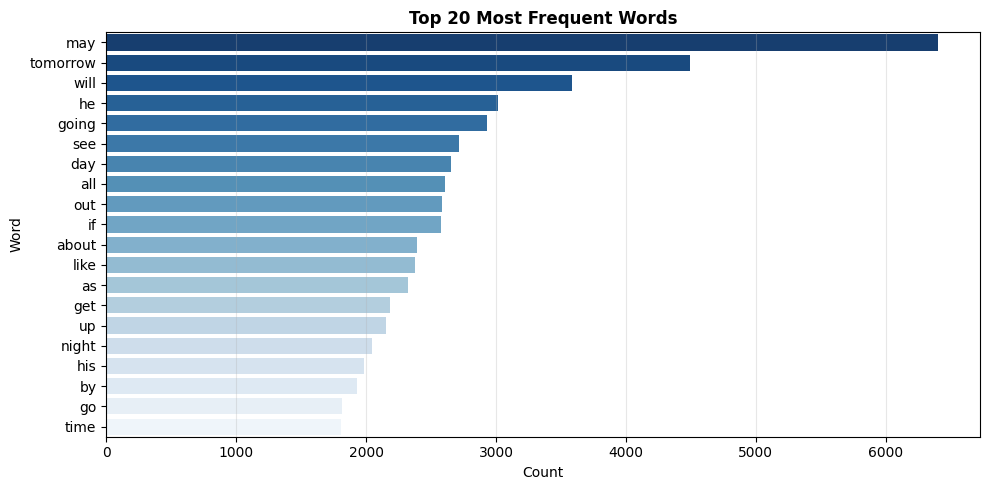

In [16]:
# Simple stopword filter for better insight
STOPWORDS = {"the","a","an","is","it","in","of","to","and","i","for","that",
             "this","on","my","me","you","at","be","was","are","have","has",
             "with","not","so","do","its","we","but","your","just","from"}

all_words   = " ".join(train_df["text"]).lower().split()
filtered    = [w for w in all_words if w not in STOPWORDS and w.isalpha()]
word_counts = Counter(filtered)
top_words   = pd.DataFrame(word_counts.most_common(20), columns=["word", "count"])

print("\n🔤 Top 20 Most Frequent Words (stopwords removed)")
print(top_words)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_words, x="count", y="word", hue="word", palette="Blues_r", legend=False)
plt.title("Top 20 Most Frequent Words", fontweight="bold")
plt.xlabel("Count"); plt.ylabel("Word")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("plot_04_top_words.png", dpi=150, bbox_inches="tight")
plt.show()

**Plot 5: Token Length Analysis (BERT tokenizer)**


🤖 Token Length Analysis (bert-base-uncased)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

count    45586.000000
mean        29.806366
std          8.480181
min          5.000000
25%         24.000000
50%         30.000000
75%         35.000000
max        116.000000
Name: text, dtype: float64

→ Sequences > 128 tokens: 0 (0.0%)
→ Sequences > 64  tokens: 61 (0.1%)


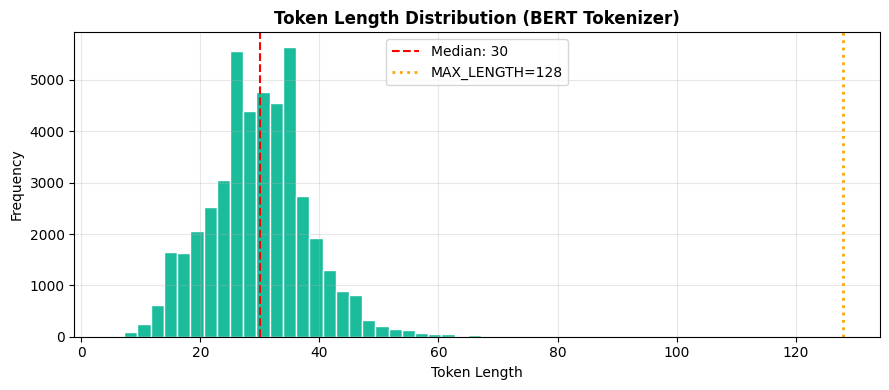

In [17]:
print("\n🤖 Token Length Analysis (bert-base-uncased)")
_tokenizer_tmp = BertTokenizerFast.from_pretrained("bert-base-uncased")
token_lengths  = train_df["text"].apply(
    lambda x: len(_tokenizer_tmp.encode(x, truncation=False))
)
print(token_lengths.describe())
print(f"\n→ Sequences > 128 tokens: {(token_lengths > 128).sum()} ({(token_lengths > 128).mean()*100:.1f}%)")
print(f"→ Sequences > 64  tokens: {(token_lengths > 64).sum()} ({(token_lengths > 64).mean()*100:.1f}%)")

plt.figure(figsize=(9, 4))
plt.hist(token_lengths, bins=50, edgecolor="white", color="#1abc9c")
plt.axvline(token_lengths.median(), color="red", linestyle="--",
            label=f"Median: {token_lengths.median():.0f}")
plt.axvline(128, color="orange", linestyle=":", linewidth=2,
            label="MAX_LENGTH=128")
plt.title("Token Length Distribution (BERT Tokenizer)", fontweight="bold")
plt.xlabel("Token Length"); plt.ylabel("Frequency")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("plot_05_token_length.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
print("\n🧪 Extreme Samples")
print("Shortest tweet:", train_df.loc[train_df["word_count"].idxmin(), "text"])
print("Longest tweet :", train_df.loc[train_df["word_count"].idxmax(), "text"])


🧪 Extreme Samples
Shortest tweet: #AmWriting
Longest tweet : This is as brutal of a loss as it gets. Up 6-0 then up 2 with 2 outs in the 9th only to blow it. It\u2019s going to be a very long winter in WSH.


### 4. PREPROCESSING & TOKENIZATION

In [19]:
# Hyperparameter
MODEL_NAME    = "bert-base-uncased"
MAX_LENGTH    = 128
BATCH_SIZE    = 32
EPOCHS        = 4          # increased from 3 for better convergence
LEARNING_RATE = 2e-5
WARMUP_RATIO  = 0.1
WEIGHT_DECAY  = 0.01
PATIENCE      = 2          # early-stopping patience

print("\n⚙️  Training Configuration")
print(f"   Model         : {MODEL_NAME}")
print(f"   Max Length    : {MAX_LENGTH}")
print(f"   Batch Size    : {BATCH_SIZE}")
print(f"   Epochs        : {EPOCHS}")
print(f"   Learning Rate : {LEARNING_RATE}")
print(f"   Weight Decay  : {WEIGHT_DECAY}")
print(f"   Warmup Ratio  : {WARMUP_RATIO}")
print(f"   Early Stop    : patience={PATIENCE}")


⚙️  Training Configuration
   Model         : bert-base-uncased
   Max Length    : 128
   Batch Size    : 32
   Epochs        : 4
   Learning Rate : 2e-05
   Weight Decay  : 0.01
   Warmup Ratio  : 0.1
   Early Stop    : patience=2


In [20]:
# Tokenizer
print("\n⏳ Loading tokenizer...")
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

print(f"✅ Vocab size     : {tokenizer.vocab_size:,}")
print(f"   Special tokens : {tokenizer.special_tokens_map}")


⏳ Loading tokenizer...
✅ Vocab size     : 30,522
   Special tokens : {'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}


In [21]:
# Tokenization demo
sample_text = train_df["text"].iloc[0]
print(f"\n📝 Sample text : {sample_text}")
print(f"   Tokens     : {tokenizer.tokenize(sample_text)}")

encoding = tokenizer(
    sample_text,
    max_length=MAX_LENGTH,
    truncation=True,
    padding="max_length",
    return_attention_mask=True,
    return_token_type_ids=True,
    return_tensors="pt",
)
print(f"\n   input_ids shape    : {encoding['input_ids'].shape}")
print(f"   attention_mask shape: {encoding['attention_mask'].shape}")
print(f"   Decoded back       : {tokenizer.decode(encoding['input_ids'][0])}")


📝 Sample text : "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"
   Tokens     : ['"', 'q', '##t', '@', 'user', 'in', 'the', 'original', 'draft', 'of', 'the', '7th', 'book', ',', 're', '##mus', 'lu', '##pin', 'survived', 'the', 'battle', 'of', 'hog', '##wart', '##s', '.', '#', 'happy', '##bir', '##th', '##day', '##rem', '##us', '##lu', '##pin', '"']

   input_ids shape    : torch.Size([1, 128])
   attention_mask shape: torch.Size([1, 128])
   Decoded back       : [CLS] " qt @ user in the original draft of the 7th book, remus lupin survived the battle of hogwarts. # happybirthdayremuslupin " [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] 

In [22]:
# Custom Dataset
class TweetSentimentDataset(Dataset):
    """
    PyTorch Dataset for Tweet Sentiment Analysis.
    Tokenizes text on-the-fly for memory efficiency.
    """
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts      = texts
        self.labels     = labels
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text  = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_token_type_ids=True,
            return_tensors="pt",
        )

        item = {
            "input_ids":      encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels":         torch.tensor(label, dtype=torch.long),
        }
        if "token_type_ids" in encoding:
            item["token_type_ids"] = encoding["token_type_ids"].squeeze(0)

        return item

In [23]:
# DataLoader
train_dataset = TweetSentimentDataset(train_df["text"].values, train_df["label"].values, tokenizer, MAX_LENGTH)
val_dataset   = TweetSentimentDataset(val_df["text"].values,   val_df["label"].values,   tokenizer, MAX_LENGTH)
test_dataset  = TweetSentimentDataset(test_df["text"].values,  test_df["label"].values,  tokenizer, MAX_LENGTH)

In [24]:
pin_memory = torch.cuda.is_available()

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=pin_memory)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=pin_memory)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=pin_memory)

In [25]:
print(f"\n📦 Dataset Sizes — Train: {len(train_dataset):,} | Val: {len(val_dataset):,} | Test: {len(test_dataset):,}")
print(f"   Batches      — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")


📦 Dataset Sizes — Train: 45,586 | Val: 2,000 | Test: 12,284
   Batches      — Train: 1425 | Val: 63 | Test: 384


In [26]:
# Sanity check
sample_batch = next(iter(train_loader))
print(f"\n🔍 Batch keys       : {list(sample_batch.keys())}")
print(f"   input_ids shape : {sample_batch['input_ids'].shape}")
print(f"   labels shape    : {sample_batch['labels'].shape}")


🔍 Batch keys       : ['input_ids', 'attention_mask', 'labels', 'token_type_ids']
   input_ids shape : torch.Size([32, 128])
   labels shape    : torch.Size([32])


### 5. MODEL BERT & OPTIMIZER

In [27]:
print("\n⏳ Loading BERT model...")
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1,
)
model = model.to(DEVICE)
print("✅ Model loaded successfully!")


⏳ Loading BERT model...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded successfully!


In [28]:
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n📊 Total parameters     : {total_params:,}")
print(f"   Trainable parameters : {trainable_params:,}")
print(f"\n🏗️  Classifier Head\n{model.classifier}")


📊 Total parameters     : 109,484,547
   Trainable parameters : 109,484,547

🏗️  Classifier Head
Linear(in_features=768, out_features=3, bias=True)


In [29]:
# Optimizer with Differential Learning Rates
# Strategy: lower LR for pretrained BERT layers, higher for classifier head
no_decay = ["bias", "LayerNorm.weight"]

optimizer_grouped_parameters = [
    # BERT encoder — with weight decay
    {
        "params": [
            p for n, p in model.named_parameters()
            if not any(nd in n for nd in no_decay) and "classifier" not in n
        ],
        "weight_decay": WEIGHT_DECAY,
        "lr": LEARNING_RATE,
    },
    # BERT encoder — without weight decay (bias & LayerNorm)
    {
        "params": [
            p for n, p in model.named_parameters()
            if any(nd in n for nd in no_decay) and "classifier" not in n
        ],
        "weight_decay": 0.0,
        "lr": LEARNING_RATE,
    },
    # Classifier head — 10x higher learning rate for faster adaptation
    {
        "params": [p for n, p in model.named_parameters() if "classifier" in n],
        "weight_decay": 0.0,
        "lr": LEARNING_RATE * 10,
    },
]

optimizer = AdamW(optimizer_grouped_parameters, eps=1e-8)
print("✅ Optimizer: AdamW with differential learning rates")
print(f"   BERT encoder LR : {LEARNING_RATE}")
print(f"   Classifier LR   : {LEARNING_RATE * 10}")

✅ Optimizer: AdamW with differential learning rates
   BERT encoder LR : 2e-05
   Classifier LR   : 0.0002


In [30]:
# Linear Warmup Scheduler
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f"\n📈 Scheduler: Linear Warmup → Linear Decay")
print(f"   Total steps  : {total_steps:,}")
print(f"   Warmup steps : {warmup_steps:,}")


📈 Scheduler: Linear Warmup → Linear Decay
   Total steps  : 5,700
   Warmup steps : 570


### 6. TRAINING LOOP

In [31]:
def train_epoch(model, dataloader, optimizer, scheduler, device):
    """Run one training epoch. Returns (avg_loss, accuracy, weighted_f1)."""
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    pbar = tqdm(dataloader, desc="  Training", leave=False)
    for batch in pbar:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)
        token_type_ids = batch.get("token_type_ids")
        if token_type_ids is not None:
            token_type_ids = token_type_ids.to(device)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            labels=labels,
        )

        loss   = outputs.loss
        logits = outputs.logits

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average="weighted")
    return avg_loss, accuracy, f1

In [32]:
def evaluate(model, dataloader, device):
    """Evaluate on a dataloader. Returns (avg_loss, accuracy, f1, preds, labels)."""
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        pbar = tqdm(dataloader, desc="  Evaluating", leave=False)
        for batch in pbar:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"].to(device)
            token_type_ids = batch.get("token_type_ids")
            if token_type_ids is not None:
                token_type_ids = token_type_ids.to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
                labels=labels,
            )

            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average="weighted")
    return avg_loss, accuracy, f1, all_preds, all_labels

In [33]:
# Main Training Loop with Early Stopping
best_val_f1       = 0.0
best_model_path   = "best_model.pt"
early_stop_count  = 0

history = {
    "train_loss": [], "val_loss": [],
    "train_acc":  [], "val_acc":  [],
    "train_f1":   [], "val_f1":   [],
}

print("\n🚀 Starting training...\n" + "=" * 60)

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    train_loss, train_acc, train_f1 = train_epoch(model, train_loader, optimizer, scheduler, DEVICE)
    val_loss,   val_acc,   val_f1, _, _ = evaluate(model, val_loader, DEVICE)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    print(f"  Train → Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}")
    print(f"  Val   → Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")

    # Save best model by validation F1
    if val_f1 > best_val_f1:
        best_val_f1      = val_f1
        early_stop_count = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"  💾 Best model saved (val_f1={best_val_f1:.4f})")
    else:
        early_stop_count += 1
        print(f"  ⚠️  No improvement ({early_stop_count}/{PATIENCE})")
        if early_stop_count >= PATIENCE:
            print("  🛑 Early stopping triggered!")
            break

print("\n" + "=" * 60)
print(f"✅ Training complete! Best Val F1: {best_val_f1:.4f}")


🚀 Starting training...

Epoch 1/4


  Training:   0%|          | 0/1425 [00:00<?, ?it/s]

  Evaluating:   0%|          | 0/63 [00:00<?, ?it/s]

  Train → Loss: 0.7167 | Acc: 0.6661 | F1: 0.6632
  Val   → Loss: 0.6144 | Acc: 0.7370 | F1: 0.7354
  💾 Best model saved (val_f1=0.7354)

Epoch 2/4


  Training:   0%|          | 0/1425 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e49ae4613a0>
Traceback (most recent call last):
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e49ae4613a0>  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
        if w.is_alive():self._shutdown_workers()

   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
      if w.is_alive():
         ^ ^ ^^^^^^^^^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    
assert self._parent_pid == os.getpid(), 'can only test a child process'  File "/usr/lib/python3

  Train → Loss: 0.3552 | Acc: 0.8577 | F1: 0.8578
  Val   → Loss: 0.7222 | Acc: 0.7440 | F1: 0.7421
  ⚠️  No improvement (1/2)

Epoch 4/4


  Training:   0%|          | 0/1425 [00:00<?, ?it/s]

  Evaluating:   0%|          | 0/63 [00:00<?, ?it/s]

  Train → Loss: 0.2401 | Acc: 0.9104 | F1: 0.9104
  Val   → Loss: 0.8506 | Acc: 0.7360 | F1: 0.7357
  ⚠️  No improvement (2/2)
  🛑 Early stopping triggered!

✅ Training complete! Best Val F1: 0.7463


### 7. EVALUATION & METRICS

**Plot 6: Training History**

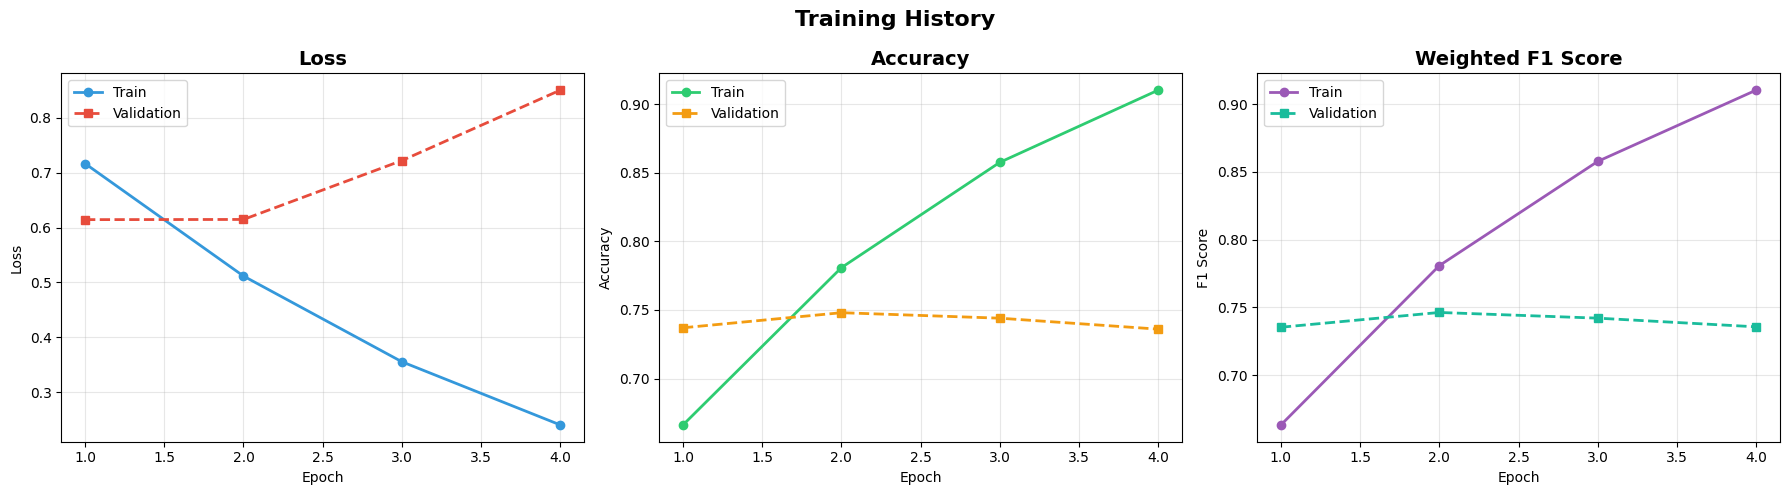

In [34]:
label_names  = ["Negative", "Neutral", "Positive"]
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_range, history["train_loss"], "o-",  label="Train",      color="#3498db", linewidth=2)
axes[0].plot(epochs_range, history["val_loss"],   "s--", label="Validation", color="#e74c3c", linewidth=2)
axes[0].set_title("Loss",     fontweight="bold", fontsize=14)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history["train_acc"], "o-",  label="Train",      color="#2ecc71", linewidth=2)
axes[1].plot(epochs_range, history["val_acc"],   "s--", label="Validation", color="#f39c12", linewidth=2)
axes[1].set_title("Accuracy", fontweight="bold", fontsize=14)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_range, history["train_f1"], "o-",  label="Train",      color="#9b59b6", linewidth=2)
axes[2].plot(epochs_range, history["val_f1"],   "s--", label="Validation", color="#1abc9c", linewidth=2)
axes[2].set_title("Weighted F1 Score", fontweight="bold", fontsize=14)
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("F1 Score")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle("Training History", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_06_training_history.png", dpi=150, bbox_inches="tight")
plt.show()

In [35]:
# Test Set Evaluation
print("\n⏳ Loading best model...")
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
print("✅ Best model loaded")

test_loss, test_acc, test_f1, test_preds, test_labels = evaluate(model, test_loader, DEVICE)

print("\n" + "=" * 50)
print("📊 TEST SET RESULTS")
print("=" * 50)
print(f"  Loss     : {test_loss:.4f}")
print(f"  Accuracy : {test_acc:.4f}  ({test_acc * 100:.2f}%)")
print(f"  F1 Score : {test_f1:.4f}")
print("=" * 50)

print("\n📋 Classification Report")
print(classification_report(test_labels, test_preds, target_names=label_names, digits=4))


⏳ Loading best model...
✅ Best model loaded


  Evaluating:   0%|          | 0/384 [00:00<?, ?it/s]


📊 TEST SET RESULTS
  Loss     : 0.6959
  Accuracy : 0.6884  (68.84%)
  F1 Score : 0.6878

📋 Classification Report
              precision    recall  f1-score   support

    Negative     0.7574    0.6060    0.6733      3972
     Neutral     0.6807    0.7201    0.6998      5937
    Positive     0.6277    0.7469    0.6822      2375

    accuracy                         0.6884     12284
   macro avg     0.6886    0.6910    0.6851     12284
weighted avg     0.6953    0.6884    0.6878     12284



**Plot 7: Confusion Matrix**

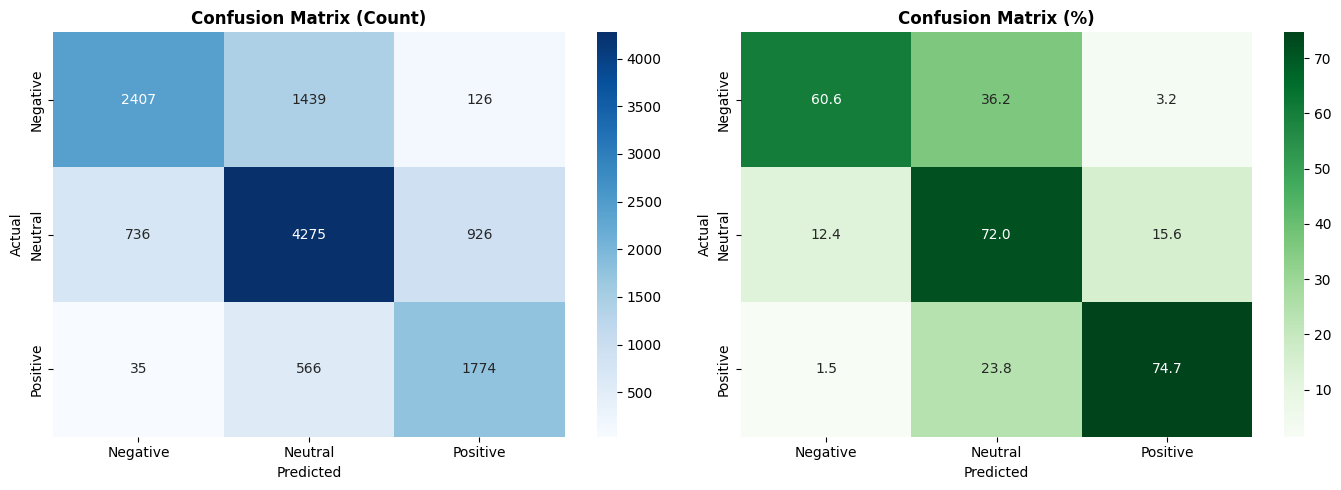

In [36]:
cm     = confusion_matrix(test_labels, test_preds)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm,     annot=True, fmt="d",   cmap="Blues",  xticklabels=label_names, yticklabels=label_names, ax=axes[0])
axes[0].set_title("Confusion Matrix (Count)", fontweight="bold")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Greens", xticklabels=label_names, yticklabels=label_names, ax=axes[1])
axes[1].set_title("Confusion Matrix (%)", fontweight="bold")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("plot_07_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

**Plot 8: F1 per Class**

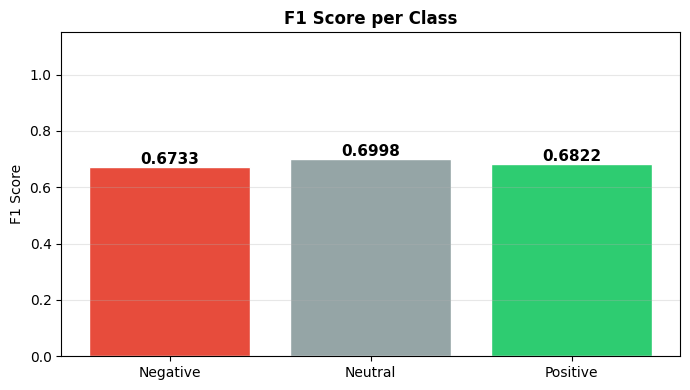

In [37]:
per_class_f1 = f1_score(test_labels, test_preds, average=None)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(label_names, per_class_f1, color=["#e74c3c", "#95a5a6", "#2ecc71"], edgecolor="white")
for bar, val in zip(bars, per_class_f1):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.4f}", ha="center", fontsize=11, fontweight="bold")
ax.set_ylim(0, 1.15)
ax.set_title("F1 Score per Class", fontweight="bold")
ax.set_ylabel("F1 Score")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("plot_08_f1_per_class.png", dpi=150, bbox_inches="tight")
plt.show()

In [38]:
# Error Analysis
errors = [
    (text, true, pred)
    for text, true, pred in zip(test_df["text"], test_labels, test_preds)
    if true != pred
]

print(f"\n❌ Total misclassified samples: {len(errors):,} / {len(test_df):,} ({len(errors)/len(test_df)*100:.1f}%)")

# Breakdown by error type
error_types = Counter(f"{label_names[t]} → {label_names[p]}" for _, t, p in errors)
print("\n📋 Error Type Breakdown:")
for err_type, count in error_types.most_common():
    print(f"   {err_type}: {count}")

print("\n--- 5 Example Misclassifications ---")
for text, true, pred in errors[:5]:
    print(f"\nText : {text}")
    print(f"True : {label_names[true]}")
    print(f"Pred : {label_names[pred]}")


❌ Total misclassified samples: 3,828 / 12,284 (31.2%)

📋 Error Type Breakdown:
   Negative → Neutral: 1439
   Neutral → Positive: 926
   Neutral → Negative: 736
   Positive → Neutral: 566
   Negative → Positive: 126
   Positive → Negative: 35

--- 5 Example Misclassifications ---

Text : @user @user what do these '1/2 naked pics' have to do with anything? They're not even like that.
True : Neutral
Pred : Negative

Text : OH: “I had a blue penis while I was this” [playing with Google Earth VR]
True : Neutral
Pred : Positive

Text : @user Wow,first Hugo Chavez and now Fidel Castro. Danny Glover, Michael Moore, Oliver Stone, and Sean Penn are running out of heroes.
True : Negative
Pred : Neutral

Text : Savchenko now Saakashvili took drug test live on Ukraine TV. To prove they are not drug-fueled loonies?
True : Neutral
Pred : Negative

Text : @user @user @user @user @user @user take away illegals and dead people and Trump wins popular vote too.
True : Negative
Pred : Neutral


### 8. INFERENCE

In [39]:
def predict_sentiment(texts, model, tokenizer, device, max_length=128, batch_size=16):
    """
    Predict sentiment for a list of texts in batches.

    Parameters
    ----------
    texts       : list of str
    model       : fine-tuned BertForSequenceClassification
    tokenizer   : BertTokenizerFast
    device      : torch.device
    max_length  : int  (default 128)
    batch_size  : int  (default 16)

    Returns
    -------
    pd.DataFrame with columns:
        text, predicted_label, label_name, confidence (%),
        prob_negative, prob_neutral, prob_positive
    """
    model.eval()
    results = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i : i + batch_size]

        encoding = tokenizer(
            batch_texts,
            max_length=max_length,
            padding=True,
            truncation=True,
            return_tensors="pt",
        )

        input_ids      = encoding["input_ids"].to(device)
        attention_mask = encoding["attention_mask"].to(device)
        token_type_ids = encoding.get("token_type_ids")
        if token_type_ids is not None:
            token_type_ids = token_type_ids.to(device)

        with torch.no_grad():
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
            )

        probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()

        for text, prob in zip(batch_texts, probs):
            pred_label = int(np.argmax(prob))
            results.append({
                "text":           text,
                "predicted_label": pred_label,
                "label_name":     LABEL_MAP[pred_label],
                "confidence":     round(float(prob[pred_label]) * 100, 2),
                "prob_negative":  round(float(prob[0]) * 100, 2),
                "prob_neutral":   round(float(prob[1]) * 100, 2),
                "prob_positive":  round(float(prob[2]) * 100, 2),
            })

    return pd.DataFrame(results)

In [40]:
# Inference on Sample Texts
sample_texts = [
    "This product is absolutely amazing! Best purchase ever.",
    "I hate this service, worst experience of my life.",
    "The package arrived on time. Nothing special.",
    "Can't believe how terrible the customer support was.",
    "Pretty good quality for the price, satisfied overall.",
    "Meh, it works but nothing impressive.",
    "Exceeded all my expectations! Highly recommend!",
    "Totally disappointed, would not buy again.",
    "It's okay, does what it says on the box.",
    "Absolutely love it! Changed my life for the better.",
    "Broken on arrival, very frustrating experience.",
    "Delivery was late but the product itself is fine.",
]

print("\n🔮 Running inference on sample texts...")
pred_df = predict_sentiment(sample_texts, model, tokenizer, DEVICE)
print(pred_df[["text", "label_name", "confidence"]].to_string(index=False))


🔮 Running inference on sample texts...
                                                   text label_name  confidence
This product is absolutely amazing! Best purchase ever.   Positive       98.97
      I hate this service, worst experience of my life.   Negative       95.78
          The package arrived on time. Nothing special.   Positive       55.07
   Can't believe how terrible the customer support was.   Negative       91.11
  Pretty good quality for the price, satisfied overall.   Positive       97.13
                  Meh, it works but nothing impressive.   Negative       58.83
        Exceeded all my expectations! Highly recommend!   Positive       98.79
             Totally disappointed, would not buy again.   Negative       87.42
               It's okay, does what it says on the box.   Positive       48.39
    Absolutely love it! Changed my life for the better.   Positive       99.09
        Broken on arrival, very frustrating experience.   Negative       91.64
      Delive

### 9. INFERENCE RESULT VISUALIZATION

**Plot 9: Per-sample Probability Bar Charts**

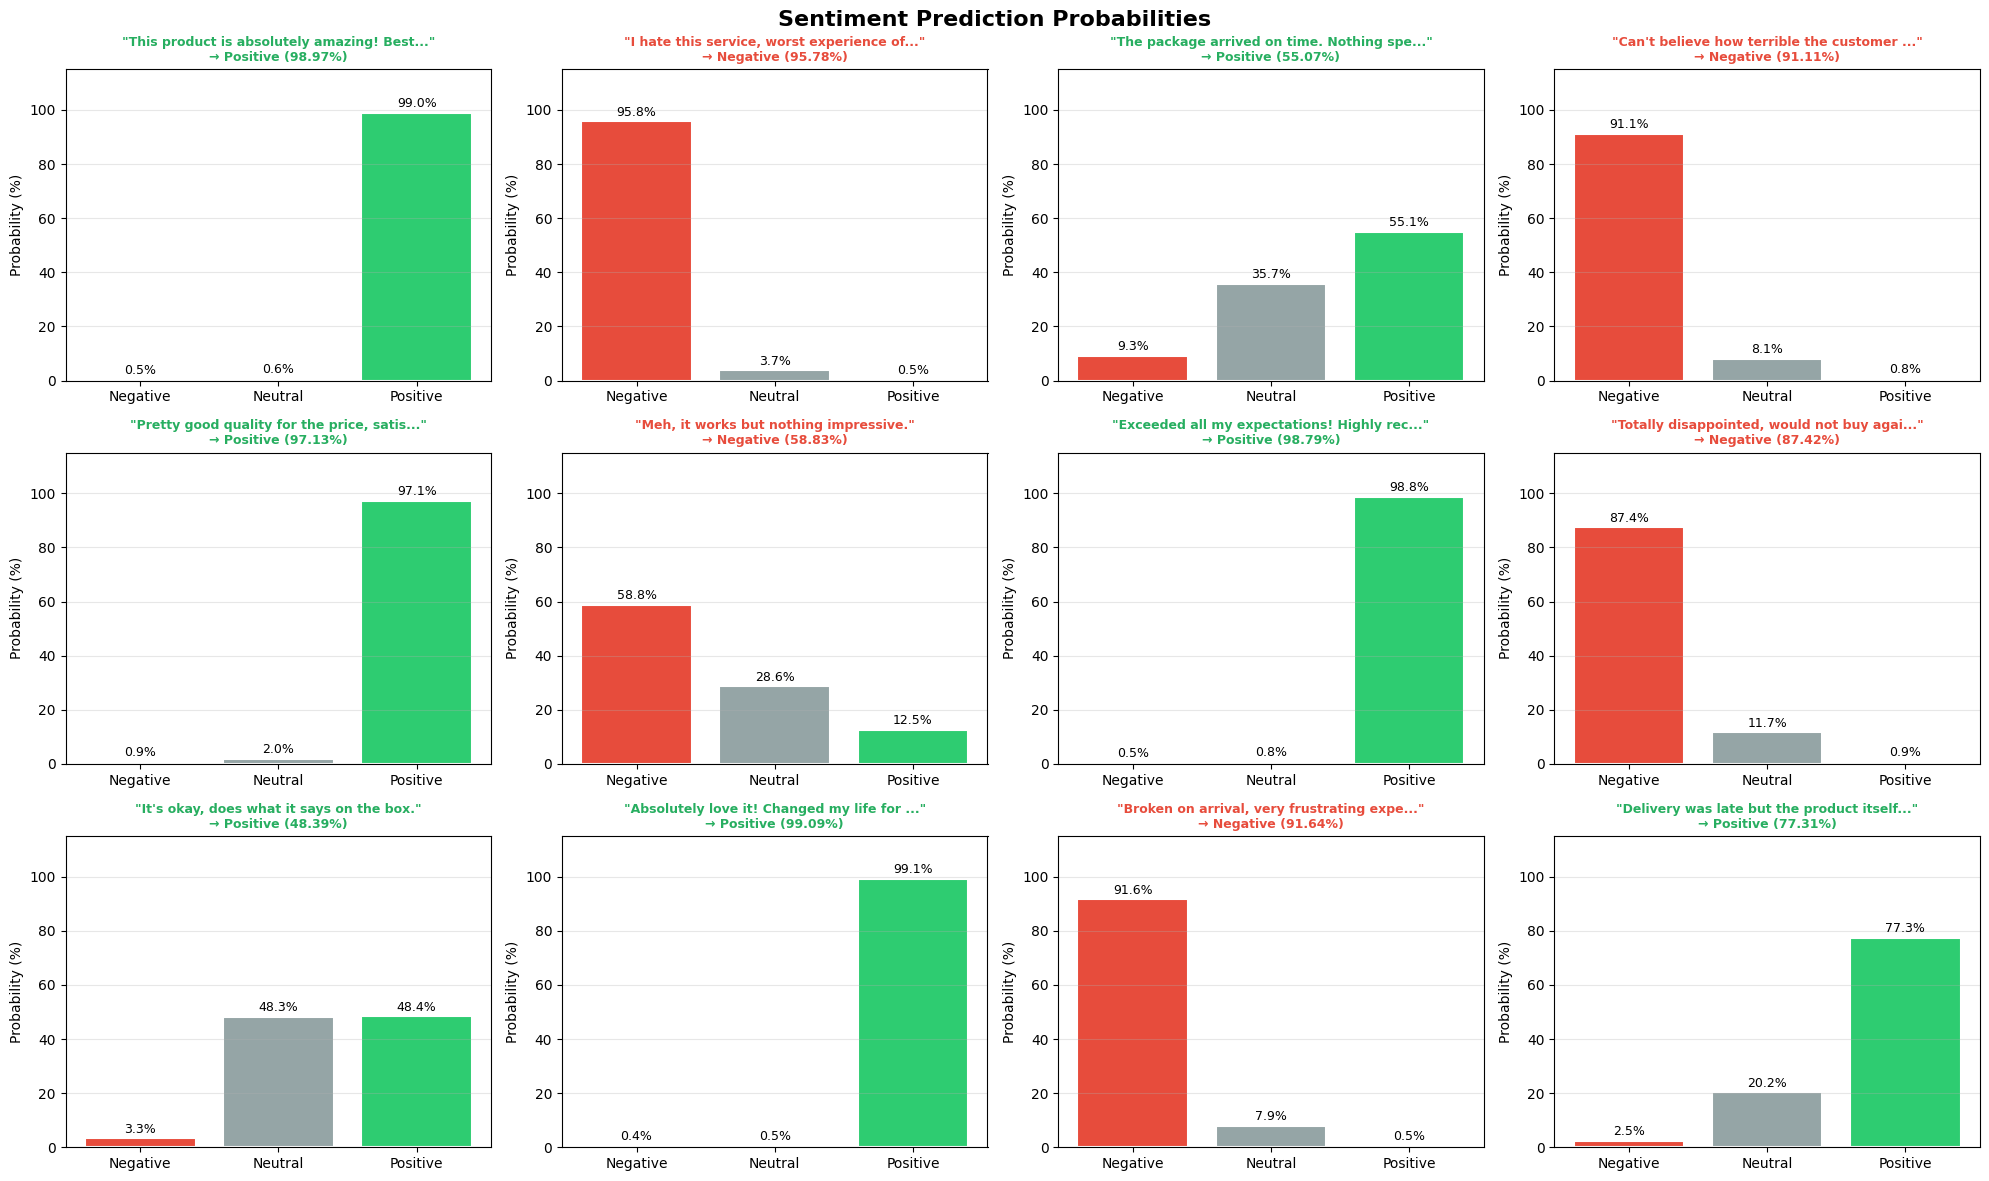

In [41]:
n_samples   = len(pred_df)
n_cols      = 4
n_rows      = (n_samples + n_cols - 1) // n_cols
colors_bar  = ["#e74c3c", "#95a5a6", "#2ecc71"]
pred_colors = {"Negative": "#e74c3c", "Neutral": "#7f8c8d", "Positive": "#27ae60"}

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, (_, row) in enumerate(pred_df.iterrows()):
    probs = [row["prob_negative"], row["prob_neutral"], row["prob_positive"]]
    bars  = axes[i].bar(label_names, probs, color=colors_bar, edgecolor="white", linewidth=1.5)

    axes[i].set_ylim(0, 115)
    for bar, val in zip(bars, probs):
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                     f"{val:.1f}%", ha="center", va="bottom", fontsize=9)

    title_text  = (row["text"][:40] + "...") if len(row["text"]) > 40 else row["text"]
    title_color = pred_colors[row["label_name"]]
    axes[i].set_title(
        f'"{title_text}"\n→ {row["label_name"]} ({row["confidence"]}%)',
        fontsize=9, color=title_color, fontweight="bold",
    )
    axes[i].set_ylabel("Probability (%)")
    axes[i].grid(axis="y", alpha=0.3)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Sentiment Prediction Probabilities", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_09_inference_results.png", dpi=150, bbox_inches="tight")
plt.show()

### 10. SAVE MODEL & SUMMARY

In [42]:
SAVE_DIR = "./saved_model"
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f"\n💾 Model & Tokenizer saved to: {SAVE_DIR}/")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


💾 Model & Tokenizer saved to: ./saved_model/


In [43]:
history_df = pd.DataFrame(history)
history_df.to_csv("training_history.csv", index=False)
print("📄 Training history saved to: training_history.csv")

📄 Training history saved to: training_history.csv


In [45]:
print("\n📌 MODEL SUMMARY")
print("=" * 60)
print(f"  Model      : {MODEL_NAME}")
print(f"  Dataset    : tweet_eval/sentiment (HuggingFace)")
print(f"  Task       : 3-class Sentiment Classification")
print(f"  Epochs run : {len(history['train_loss'])} / {EPOCHS}")
print(f"  Batch Size : {BATCH_SIZE}")
print(f"  LR         : {LEARNING_RATE}")
print("-" * 60)
print(f"  ✅ Test Accuracy : {test_acc * 100:.2f}%")
print(f"  ✅ Test F1 Score : {test_f1:.4f}")
print(f"  ✅ Test Loss     : {test_loss:.4f}")
print(f"  ✅ Best Val F1   : {best_val_f1:.4f}")
print("=" * 60)


📌 MODEL SUMMARY
  Model      : bert-base-uncased
  Dataset    : tweet_eval/sentiment (HuggingFace)
  Task       : 3-class Sentiment Classification
  Epochs run : 4 / 4
  Batch Size : 32
  LR         : 2e-05
------------------------------------------------------------
  ✅ Test Accuracy : 68.84%
  ✅ Test F1 Score : 0.6878
  ✅ Test Loss     : 0.6959
  ✅ Best Val F1   : 0.7463


### CONCLUSION

**Key Achievement    :**

Successfully developed a BERT-based sentiment analysis model using the tweet_eval/sentiment dataset to classify tweets into Negative, Neutral, and Positive sentiments. The project covers a complete NLP pipeline including EDA, preprocessing, model fine-tuning, evaluation, error analysis, and inference visualization using the HuggingFace Transformers and PyTorch framework.

---

**Performance        :**

The fine-tuned BERT (bert-base-uncased) model achieved:

- **Test Accuracy** : 68.84%

- **Test F1 Score** : 0.6878

- **Best Validation F1 Score** : 0.7463

The training history shows that the model successfully learned contextual patterns from tweets, although validation performance plateaued after several epochs, indicating potential overfitting beyond the optimal training point.

---

**Business Insight   :**

This sentiment analysis model can be applied to social media monitoring and customer feedback analysis.
Organizations can automatically classify public opinions from platforms like Twitter to:

- monitor brand perception

- detect negative feedback early

- analyze customer satisfaction trends

- support data-driven decision making in marketing and product development

---

**Future Improvement :**

Several improvements can further enhance the model performance:

- Hyperparameter tuning (learning rate, batch size, training epochs)

- Using domain-specific datasets or larger social media corpora

- Experimenting with more advanced transformer models such as RoBERTa, DistilBERT, or DeBERTa

- Applying data augmentation or class balancing techniques

- Deploying the model as a real-time sentiment analysis API or web application